# Évaluation des 4 modèles sur Mapillary Vistas v1.2

**Modèles testés :** SegFormer-B5, Mask2Former-SwinB, DeepLabV3+-R101, HRNet-W48

**Dataset :** Mapillary Vistas v1.2 — validation set (2000 images street-level, GT pixel-accurate)

**Pipeline :**
1. Chargement images RGB + GT (65 classes Vistas) du val set
2. **Mapping Vistas (65 classes) → Cityscapes (19 classes)** pour évaluer les modèles entraînés sur Cityscapes
3. Inférence avec accumulation de la matrice de confusion (memory-efficient)
4. Calcul **mIoU + IoU par classe** + vitesse + distribution
5. Visualisation segmentée avec étiquettes de classe par segment

**Note importante :** Les modèles ont été entraînés sur Cityscapes (Allemagne). Vistas est un dataset **mondial et plus diversifié** (météo, éclairage, géographie, types d'appareils). C'est un test de **généralisation cross-domain** — les mIoU seront plus bas que sur Cityscapes val. C'est attendu et constitue justement un résultat intéressant pour ton rapport CoolPath.


## 1. Environnement

In [1]:
import sys, torch
print(f"Python : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")

print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go")

import mmseg
print(f"mmsegmentation : {mmseg.__version__}")


Python : 3.10.20
PyTorch : 2.1.0+cu118
GPU : NVIDIA GeForce RTX 2060
VRAM : 6.4 Go
mmsegmentation : 1.2.2


## 2. Chemins et paramètres

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("..").resolve()
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"

# Mapillary Vistas v1.2 — chemin local
VISTAS_ROOT = Path(r"C:\Users\youss\Downloads\coolpath_local\data\mapillary_vistas")
VAL_IMG_DIR = VISTAS_ROOT / "validation" / "images"
VAL_LBL_DIR = VISTAS_ROOT / "validation" / "labels"

OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / "vistas_eval_4models"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Paramètres d'évaluation
N_IMAGES = None       # None = toutes les 2000 images du val ; mettre 50 pour test rapide
MAX_HEIGHT = 1024     # Resize hauteur max avant inférence (mémoire VRAM 6 Go)

# Listage des images val
val_images = sorted(VAL_IMG_DIR.glob("*.jpg"))
if N_IMAGES is not None:
    val_images = val_images[:N_IMAGES]

print(f"Vistas root : {VISTAS_ROOT}")
print(f"Images val  : {len(val_images)}")
print(f"MAX_HEIGHT  : {MAX_HEIGHT} px")
print(f"Output      : {OUTPUT_DIR}")


Vistas root : C:\Users\youss\Downloads\coolpath_local\data\mapillary_vistas
Images val  : 2000
MAX_HEIGHT  : 1024 px
Output      : C:\Users\youss\Downloads\coolpath_local\data\outputs\vistas_eval_4models


## 3. Config HRNet-W48

In [3]:
# Chemin vers le config HR18 installé avec mmseg (base requis par _base_)
mmseg_root = Path(mmseg.__file__).parent
hr18_src = mmseg_root / ".mim" / "configs" / "hrnet" / "fcn_hr18_4xb2-160k_cityscapes-512x1024.py"

hrnet_cfg_path = CHECKPOINTS_DIR / "fcn_hr48_4xb2-160k_cityscapes-512x1024.py"

hrnet_cfg_content = f"""_base_ = r'{hr18_src.as_posix()}'
model = dict(
    pretrained='open-mmlab://msra/hrnetv2_w48',
    backbone=dict(
        extra=dict(
            stage2=dict(num_channels=(48, 96)),
            stage3=dict(num_channels=(48, 96, 192)),
            stage4=dict(num_channels=(48, 96, 192, 384))
        )
    ),
    decode_head=dict(
        in_channels=[48, 96, 192, 384],
        channels=sum([48, 96, 192, 384])
    )
)
"""
hrnet_cfg_path.write_text(hrnet_cfg_content.strip(), encoding="utf-8")
print(f"OK  {hrnet_cfg_path.name}")


OK  fcn_hr48_4xb2-160k_cityscapes-512x1024.py


## 4. Configuration des 4 modèles

In [4]:
patterns = {
    "SegFormer-B5": (
        "segformer_mit-b5_8xb1-160k_cityscapes-1024x1024",
        "segformer_mit-b5_*.pth",
    ),
    "Mask2Former-SwinB": (
        "mask2former_swin-b-in22k-384x384-pre_8xb2-90k_cityscapes-512x1024",
        "mask2former_swin-b*.pth",
    ),
    "DeepLabV3+-R101": (
        "deeplabv3plus_r101-d8_4xb2-80k_cityscapes-512x1024",
        "deeplabv3plus_r101-d8_*.pth",
    ),
    "HRNet-W48": (
        "fcn_hr48_4xb2-160k_cityscapes-512x1024",
        "fcn_hr48_*.pth",
    ),
}

MMSEG_CONFIG = {}
for name, (config_basename, pth_pattern) in patterns.items():
    config_path = CHECKPOINTS_DIR / f"{config_basename}.py"
    pth_files = list(CHECKPOINTS_DIR.glob(pth_pattern))
    if pth_files and config_path.exists():
        MMSEG_CONFIG[name] = {"config": config_path, "checkpoint": pth_files[0]}
        print(f"  {name:<25s} OK")
    else:
        print(f"  {name:<25s} MANQUANT")

print(f"\n{len(MMSEG_CONFIG)}/{len(patterns)} modeles prets")


  SegFormer-B5              OK
  Mask2Former-SwinB         OK
  DeepLabV3+-R101           OK
  HRNet-W48                 OK

4/4 modeles prets


## 5. Mapping Vistas v1.2 (65 classes) → Cityscapes (19 classes)

Table de correspondance standard (utilisée dans DAFormer, HRDA, et la littérature de domain adaptation street-scene).

**Principe :** chaque classe Vistas est mappée vers une classe Cityscapes équivalente, ou vers `255` (ignore) si pas d'équivalent. Les pixels `ignore` sont exclus du calcul de mIoU.

**Exemples de mapping :**
- Vistas `construction--flat--road` (13) → Cityscapes `road` (0)
- Vistas `construction--flat--sidewalk` (15) → Cityscapes `sidewalk` (1)
- Vistas `nature--vegetation` (30) → Cityscapes `vegetation` (8)
- Vistas `object--banner` (32) → **ignore** (pas dans Cityscapes)
- Vistas `void--unlabeled` (65) → **ignore**


In [5]:
# Mapping officiel Vistas v1.2 (65 classes, 0-64) → Cityscapes 19 classes
# Tout ID Vistas non listé ici est mappé vers 255 (ignore)
VISTAS_V12_TO_CITYSCAPES = {
    # Vistas_id : Cityscapes_id
    13: 0,   # construction--flat--road       → road
    24: 0,   # marking--general               → road
    41: 0,   # object--manhole                → road
    8:  0,   # construction--flat--crosswalk-plain → road
    23: 0,   # marking--crosswalk-zebra       → road
    14: 0,   # construction--flat--service-lane → road

    2:  1,   # construction--barrier--curb    → sidewalk
    15: 1,   # construction--flat--sidewalk   → sidewalk
    7:  1,   # construction--flat--bike-lane  → sidewalk
    9:  1,   # construction--flat--curb-cut   → sidewalk
    11: 1,   # construction--flat--pedestrian-area → sidewalk

    17: 2,   # construction--structure--building → building

    6:  3,   # construction--barrier--wall    → wall

    3:  4,   # construction--barrier--fence       → fence
    4:  4,   # construction--barrier--guard-rail  → fence
    5:  4,   # construction--barrier--other-barrier → fence

    45: 5,   # object--support--pole              → pole
    47: 5,   # object--support--utility-pole      → pole
    46: 5,   # object--support--traffic-sign-frame → pole

    48: 6,   # object--traffic-light          → traffic_light

    50: 7,   # object--traffic-sign--front    → traffic_sign
    49: 7,   # object--traffic-sign--back     → traffic_sign

    30: 8,   # nature--vegetation             → vegetation

    29: 9,   # nature--terrain                → terrain
    26: 9,   # nature--sand                   → terrain

    27: 10,  # nature--sky                    → sky

    19: 11,  # human--person                  → person

    20: 12,  # human--rider--bicyclist        → rider
    21: 12,  # human--rider--motorcyclist     → rider
    22: 12,  # human--rider--other-rider      → rider

    55: 13,  # object--vehicle--car           → car

    61: 14,  # object--vehicle--truck         → truck

    54: 15,  # object--vehicle--bus           → bus

    58: 16,  # object--vehicle--on-rails      → train

    57: 17,  # object--vehicle--motorcycle    → motorcycle

    52: 18,  # object--vehicle--bicycle       → bicycle
}

# Table de lookup compacte (taille 256 pour gérer tous les uint8 possibles)
VISTAS_LUT = np.full(256, 255, dtype=np.uint8)  # par défaut : ignore (255)
for vistas_id, cs_id in VISTAS_V12_TO_CITYSCAPES.items():
    VISTAS_LUT[vistas_id] = cs_id

print(f"Mapping : {len(VISTAS_V12_TO_CITYSCAPES)} classes Vistas → 19 classes Cityscapes")
print(f"Classes Vistas ignorées : {65 - len(VISTAS_V12_TO_CITYSCAPES)} (mappées vers 255)")


Mapping : 36 classes Vistas → 19 classes Cityscapes
Classes Vistas ignorées : 29 (mappées vers 255)


## 6. Palette Cityscapes et labels

In [6]:
import matplotlib.pyplot as plt

CITYSCAPES_PALETTE = np.array([
    [128,  64, 128], [244,  35, 232], [ 70,  70,  70], [102, 102, 156], [190, 153, 153],
    [153, 153, 153], [250, 170,  30], [220, 220,   0], [107, 142,  35], [152, 251, 152],
    [ 70, 130, 180], [220,  20,  60], [255,   0,   0], [  0,   0, 142], [  0,   0,  70],
    [  0,  60, 100], [  0,  80, 100], [  0,   0, 230], [119,  11,  32],
], dtype=np.uint8)

CITYSCAPES_LABELS = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic_light",
    "traffic_sign", "vegetation", "terrain", "sky", "person", "rider",
    "car", "truck", "bus", "train", "motorcycle", "bicycle",
]


def colorize(mask):
    """Convertit un mask 19-classes (avec 255=ignore) en image RGB."""
    out = np.zeros((*mask.shape, 3), dtype=np.uint8)
    valid = mask < 19
    out[valid] = CITYSCAPES_PALETTE[mask[valid]]
    return out


print("Palette + labels prêts.")


Palette + labels prêts.


## 7. Utilitaires : resize images Vistas

In [7]:
from PIL import Image
import cv2

def load_image_resized(img_path, max_height=MAX_HEIGHT):
    """Charge une image Vistas et la redimensionne (hauteur max)."""
    img = Image.open(img_path).convert("RGB")
    w, h = img.size
    if h > max_height:
        scale = max_height / h
        new_w = int(w * scale)
        new_h = max_height
        img = img.resize((new_w, new_h), Image.BILINEAR)
    return img


def load_gt_mapped(lbl_path, target_size):
    """Charge un GT Vistas, applique le mapping, et resize vers target_size.
    
    target_size : (width, height) — taille de l'image après resize.
    Retourne un array uint8 avec valeurs 0..18 ou 255 (ignore).
    """
    gt = np.array(Image.open(lbl_path))  # uint8, valeurs 0..65
    gt_mapped = VISTAS_LUT[gt]            # 19 classes ou 255
    # Resize avec interpolation NEAREST pour préserver les labels
    gt_resized = cv2.resize(gt_mapped, target_size, interpolation=cv2.INTER_NEAREST)
    return gt_resized


# Test rapide sur la première image
test_img = load_image_resized(val_images[0])
test_gt = load_gt_mapped(VAL_LBL_DIR / (val_images[0].stem + ".png"), test_img.size)
print(f"Image resized : {test_img.size}")
print(f"GT mapped      : {test_gt.shape}, classes uniques = {np.unique(test_gt)}")


Image resized : (1365, 1024)
GT mapped      : (1024, 1365), classes uniques = [  0   1   2   3   4   5   6   7   8  10  11  13  14 255]


## 8. Inférence + matrice de confusion (memory-efficient)

Pour chaque modèle :
- Charge le modèle, warmup
- Pour chaque image val :
  - Resize image, charge GT mappée, prédit
  - **Accumule la matrice de confusion 19×19**
  - Mesure le temps
  - Accumule la distribution des classes prédites
- Sauvegarde la prédiction uniquement pour 3 images témoins (visualisation)
- Libère le modèle

Approche standard mIoU : on garde **uniquement la matrice de confusion** (19×19 = 361 entiers) au lieu de stocker toutes les prédictions (qui rempliraient 16 Go de RAM).

In [22]:
from mmseg.apis import init_model, inference_model
import time
import pickle
import random

NUM_CLASSES = 19
IGNORE_LABEL = 255
CHECKPOINT_EVERY = 50    # Sauvegarde tous les N images

STATE_DIR = OUTPUT_DIR / "run_state"
STATE_DIR.mkdir(parents=True, exist_ok=True)

random.seed(42)
SAMPLE_NAMES = set(random.sample([p.name for p in val_images], min(10, len(val_images))))
print(f"Images témoins : {SAMPLE_NAMES}")
print(f"Checkpoints d'état : {STATE_DIR}")
print(f"Sauvegarde tous les {CHECKPOINT_EVERY} images\n")


def save_state(model_name, state):
    """Sauvegarde atomique : écrit dans .tmp puis renomme (resilient à Ctrl+C)."""
    tmp = STATE_DIR / f"{model_name}.pkl.tmp"
    final = STATE_DIR / f"{model_name}.pkl"
    with open(tmp, "wb") as f:
        pickle.dump(state, f)
    tmp.replace(final)


def load_state(model_name):
    path = STATE_DIR / f"{model_name}.pkl"
    if not path.exists():
        return None
    with open(path, "rb") as f:
        return pickle.load(f)


def compute_confusion_matrix_update(gt, pred, num_classes=NUM_CLASSES):
    mask = gt != IGNORE_LABEL
    gt_v = gt[mask]
    pr_v = np.clip(pred[mask], 0, num_classes - 1)
    idx = gt_v.astype(np.int64) * num_classes + pr_v.astype(np.int64)
    return np.bincount(idx, minlength=num_classes * num_classes).reshape(num_classes, num_classes)


def run_model_on_vistas(model_name, config_path, checkpoint_path, val_images):
    print(f"\n{'='*65}")
    print(f"  {model_name}")
    print(f"{'='*65}")

    # Vérification checkpoint existant
    state = load_state(model_name)
    if state is not None and state.get("completed", False):
        print(f"  DÉJÀ COMPLET ({len(state['times'])} images) — chargé depuis checkpoint")
        return state

    if state is None:
        state = {
            "confusion": np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64),
            "times": [],
            "class_counts": np.zeros(NUM_CLASSES, dtype=np.int64),
            "sample_preds": {},
            "processed_names": [],
            "completed": False,
        }

    processed = set(state["processed_names"])
    remaining = [p for p in val_images if p.name not in processed]
    n_done = len(processed)
    n_total = len(val_images)

    if n_done > 0:
        print(f"  REPRISE : {n_done}/{n_total} déjà traitées, reste {len(remaining)}\n")
    else:
        print(f"  Démarrage : 0/{n_total}\n")

    if not remaining:
        state["completed"] = True
        save_state(model_name, state)
        return stat

    model = init_model(str(config_path), str(checkpoint_path), device="cuda:0")

    # Warmup seulement si nouveau run
    if n_done == 0:
        _ = inference_model(model, np.array(load_image_resized(val_images[0])))
        torch.cuda.synchronize()

    t_start = time.perf_counter()

    for j, img_path in enumerate(remaining, 1):
        lbl_path = VAL_LBL_DIR / (img_path.stem + ".png")
        img = load_image_resized(img_path)
        img_arr = np.array(img)
        gt = load_gt_mapped(lbl_path, img.size)

        torch.cuda.synchronize()
        t0 = time.perf_counter()
        result = inference_model(model, img_arr)
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0

        pred = result.pred_sem_seg.data[0].cpu().numpy().astype(np.uint8)

        # Update state
        state["confusion"] += compute_confusion_matrix_update(gt, pred)
        state["times"].append(elapsed)
        state["class_counts"] += np.bincount(pred.ravel(), minlength=NUM_CLASSES)[:NUM_CLASSES].astype(np.int64)
        if img_path.name in SAMPLE_NAMES:
            state["sample_preds"][img_path.name] = {
                "image": img_arr, "gt": gt, "pred": pred,
            }
        state["processed_names"].append(img_path.name)

        # Sauvegarde périodique
        if j % CHECKPOINT_EVERY == 0:
            save_state(model_name, state)

        total_done = n_done + j
        if total_done % 25 == 0 or j == len(remaining):
            elapsed_total = time.perf_counter() - t_start
            avg = elapsed_total / j
            eta = avg * (len(remaining) - j)
            print(f"    [{total_done:>4}/{n_total}]  avg={avg*1000:6.0f}ms  ETA={eta/60:5.1f}min")

    state["completed"] = True
    save_state(model_name, state)

    del model
    torch.cuda.empty_cache()
    return state


all_results = {}
for model_name, cfg in MMSEG_CONFIG.items():
    all_results[model_name] = run_model_on_vistas(
        model_name, cfg["config"], cfg["checkpoint"], val_images
    )

print(f"\n=== Inference terminée ({len(all_results)} modèles) ===")

Images témoins : {'5gEY38kEOGdXzal_RKJpaA.jpg', 'oJAdhUthZ3TD6plOYFciKg.jpg', '7GX8DVGcbajiJfn7xJbpUw.jpg', 'BfKp88YxoeTWyNGyD1KPVw.jpg', 'ASbiu8iObBT2iXL1LPzjkQ.jpg', 'rMqdTNhQ3gk2fFheVYQaug.jpg', 'RQh5exRs_Kxnu-I5Vnaxaw.jpg', '0wcA84wys1Ag1X-_L8PreA.jpg', 'cDvtKnuYMm7IXAUpybkkaQ.jpg', '5xXH_FtKsUhNSeOgfjUUqg.jpg'}
Checkpoints d'état : C:\Users\youss\Downloads\coolpath_local\data\outputs\vistas_eval_4models\run_state
Sauvegarde tous les 50 images


  SegFormer-B5
  DÉJÀ COMPLET (2000 images) — chargé depuis checkpoint

  Mask2Former-SwinB
  DÉJÀ COMPLET (2000 images) — chargé depuis checkpoint

  DeepLabV3+-R101
  DÉJÀ COMPLET (2000 images) — chargé depuis checkpoint

  HRNet-W48
  DÉJÀ COMPLET (2000 images) — chargé depuis checkpoint

=== Inference terminée (4 modèles) ===


In [23]:
first_model = next(iter(all_results.keys()))
print(len(all_results[first_model]["sample_preds"]))
print(list(all_results[first_model]["sample_preds"].keys()))

3
['0wcA84wys1Ag1X-_L8PreA.jpg', '5xXH_FtKsUhNSeOgfjUUqg.jpg', 'oJAdhUthZ3TD6plOYFciKg.jpg']


In [9]:
import pickle

STATE_DIR = OUTPUT_DIR / "run_state"
STATE_DIR.mkdir(parents=True, exist_ok=True)

for name, res in all_results.items():
    state = {
        "confusion": res["confusion"],
        "times": res["times"],
        "class_counts": res["class_counts"],
        "sample_preds": res["sample_preds"],
        "processed_names": [p.name for p in val_images],
        "completed": True,
    }
    with open(STATE_DIR / f"{name}.pkl", "wb") as f:
        pickle.dump(state, f)
    print(f"OK  {name}  ({len(res['times'])} images)")

print(f"\nÉtats sauvegardés dans {STATE_DIR}")

OK  SegFormer-B5  (2000 images)
OK  Mask2Former-SwinB  (2000 images)
OK  DeepLabV3+-R101  (2000 images)
OK  HRNet-W48  (2000 images)

États sauvegardés dans C:\Users\youss\Downloads\coolpath_local\data\outputs\vistas_eval_4models\run_state


## 9. mIoU + IoU par classe

Calcul standard à partir de la matrice de confusion :
$$\text{IoU}_c = \frac{TP_c}{TP_c + FP_c + FN_c}$$
$$\text{mIoU} = \frac{1}{N} \sum_c \text{IoU}_c$$

In [10]:
def confusion_to_iou(cm):
    """Calcule l'IoU par classe + mIoU à partir d'une matrice de confusion 19x19."""
    tp = np.diag(cm).astype(np.float64)
    fp = cm.sum(axis=0).astype(np.float64) - tp
    fn = cm.sum(axis=1).astype(np.float64) - tp
    denom = tp + fp + fn
    iou = np.where(denom > 0, tp / denom, np.nan)
    miou = np.nanmean(iou)
    return iou, miou


iou_per_class = {}
miou_per_model = {}
for model_name, res in all_results.items():
    iou, miou = confusion_to_iou(res["confusion"])
    iou_per_class[model_name] = iou
    miou_per_model[model_name] = miou


# Tableau IoU par classe
iou_df = pd.DataFrame(iou_per_class, index=CITYSCAPES_LABELS)
iou_df.loc["mIoU"] = pd.Series(miou_per_model)
iou_df = (iou_df * 100).round(2)
iou_df.to_csv(OUTPUT_DIR / "iou_per_class.csv")
print("=== IoU par classe (%) sur Vistas val ===\n")
print(iou_df.to_string())
print(f"\n=== mIoU global ===\n")
for name, miou in sorted(miou_per_model.items(), key=lambda x: -x[1]):
    print(f"  {name:<25s} {miou*100:6.2f} %")


=== IoU par classe (%) sur Vistas val ===

               SegFormer-B5  Mask2Former-SwinB  DeepLabV3+-R101  HRNet-W48
road                  85.39              86.80            84.47      84.12
sidewalk              37.31              39.30            34.67      36.39
building              69.71              65.17            37.98      68.54
wall                  27.77              32.11            23.38      22.97
fence                 38.90              41.16            32.79      32.34
pole                  52.63              53.99            35.95      38.08
traffic_light         50.50              58.79            38.36      46.80
traffic_sign          61.34              66.87            46.84      58.05
vegetation            86.75              88.30            82.53      83.81
terrain               45.63              51.10            41.35      40.70
sky                   86.93              82.50            36.79      86.79
person                74.33              77.26           

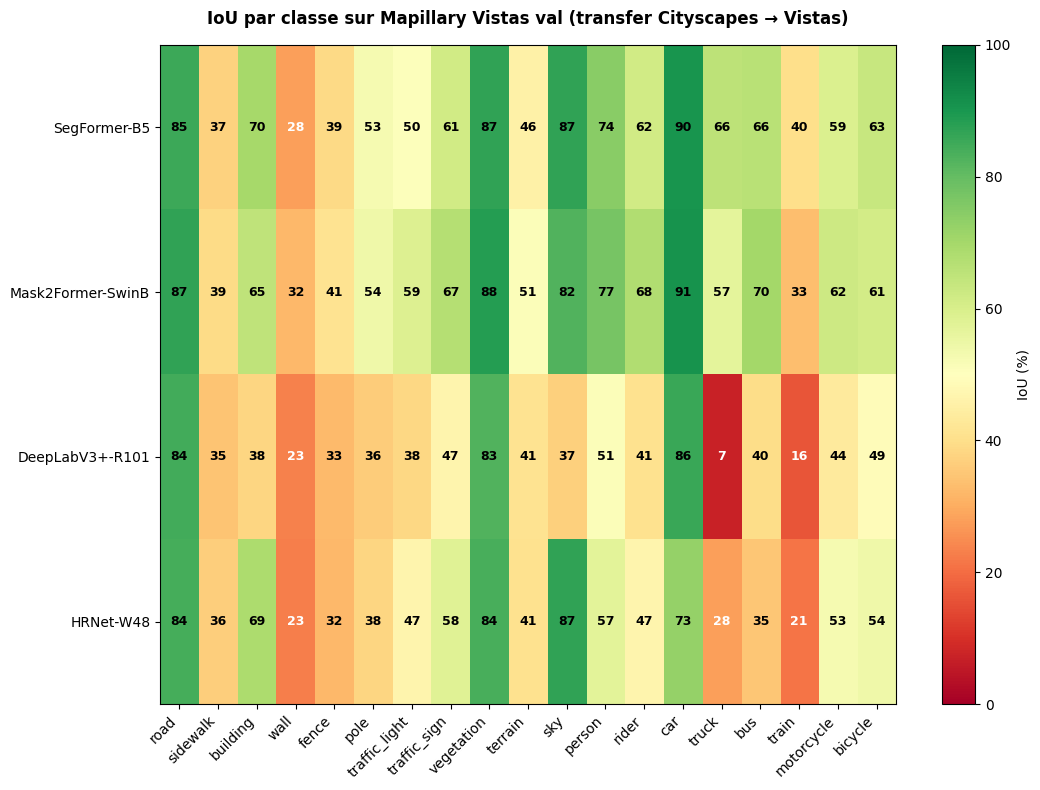

In [11]:
# Heatmap IoU par classe
fig, ax = plt.subplots(figsize=(11, 8))

heatmap_data = iou_df.iloc[:-1].T   # exclure ligne mIoU
im = ax.imshow(heatmap_data.values, cmap="RdYlGn", vmin=0, vmax=100, aspect="auto")

for i in range(heatmap_data.shape[0]):
    for j in range(heatmap_data.shape[1]):
        val = heatmap_data.iloc[i, j]
        color = "white" if val < 30 else "black"
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                color=color, fontsize=9, fontweight="bold")

ax.set_xticks(range(len(CITYSCAPES_LABELS)))
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_xticklabels(CITYSCAPES_LABELS, rotation=45, ha="right")
ax.set_yticklabels(heatmap_data.index)
ax.set_title("IoU par classe sur Mapillary Vistas val (transfer Cityscapes → Vistas)",
             fontweight="bold", pad=15)
plt.colorbar(im, ax=ax, label="IoU (%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "iou_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()


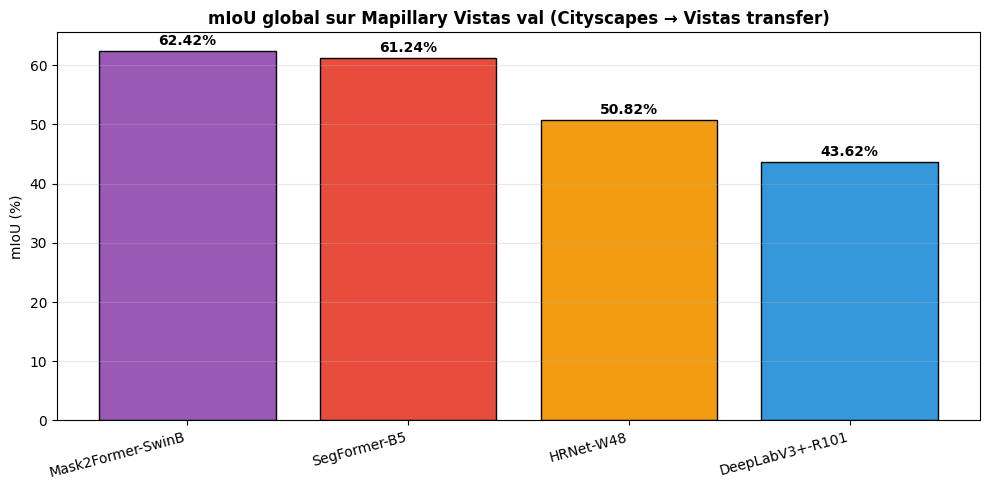

In [12]:
# Bar chart mIoU global
fig, ax = plt.subplots(figsize=(10, 5))
sorted_items = sorted(miou_per_model.items(), key=lambda x: -x[1])
names = [x[0] for x in sorted_items]
mious = [x[1] * 100 for x in sorted_items]

colors = ["#9b59b6", "#e74c3c", "#f39c12", "#3498db"][:len(names)]
bars = ax.bar(names, mious, color=colors, edgecolor="black")
for bar, val in zip(bars, mious):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.2f}%", ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("mIoU (%)")
ax.set_title("mIoU global sur Mapillary Vistas val (Cityscapes → Vistas transfer)",
             fontweight="bold")
ax.grid(axis="y", alpha=0.3)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "miou_comparison.png", dpi=110, bbox_inches="tight")
plt.show()


## 10. Vitesse d'inférence

In [13]:
speed_data = {}
for name, res in all_results.items():
    arr = np.array(res["times"]) * 1000
    speed_data[name] = {
        "n_images": len(arr),
        "mean_ms": arr.mean(),
        "median_ms": np.median(arr),
        "std_ms": arr.std(),
        "fps": 1000.0 / arr.mean(),
        "mIoU_%": miou_per_model[name] * 100,
    }

speed_df = pd.DataFrame(speed_data).T.sort_values("fps", ascending=False)
speed_df.to_csv(OUTPUT_DIR / "speed_metrics.csv")
print(speed_df.round(2).to_string())


                   n_images  mean_ms  median_ms  std_ms   fps  mIoU_%
HRNet-W48            2000.0   496.61     518.41   80.51  2.01   50.82
Mask2Former-SwinB    2000.0   743.15     706.95  108.80  1.35   62.42
DeepLabV3+-R101      2000.0   921.87     821.05  408.30  1.08   43.62
SegFormer-B5         2000.0  1003.38     916.46  194.84  1.00   61.24


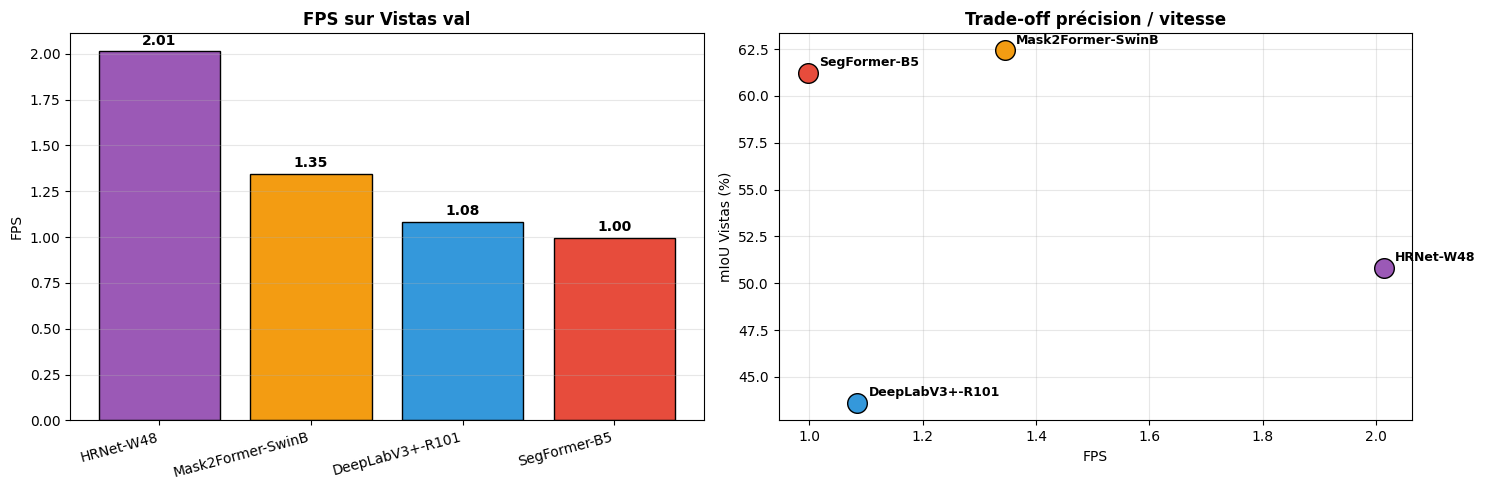

In [14]:
# Chart vitesse + Pareto mIoU vs FPS
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

models = list(speed_df.index)
fps_vals = speed_df["fps"].values
miou_vals = speed_df["mIoU_%"].values
colors_map = {"SegFormer-B5": "#e74c3c", "Mask2Former-SwinB": "#f39c12",
              "DeepLabV3+-R101": "#3498db", "HRNet-W48": "#9b59b6"}
colors = [colors_map[m] for m in models]

# Bar chart FPS
bars = axes[0].bar(models, fps_vals, color=colors, edgecolor="black")
for bar, val in zip(bars, fps_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", va="bottom", fontweight="bold")
axes[0].set_ylabel("FPS")
axes[0].set_title("FPS sur Vistas val", fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=15, ha="right")

# Pareto mIoU vs FPS
for m, f, mi in zip(models, fps_vals, miou_vals):
    axes[1].scatter(f, mi, s=200, color=colors_map[m], edgecolor="black",
                    label=m, zorder=3)
    axes[1].annotate(m, (f, mi), xytext=(8, 5), textcoords="offset points",
                     fontsize=9, fontweight="bold")
axes[1].set_xlabel("FPS")
axes[1].set_ylabel("mIoU Vistas (%)")
axes[1].set_title("Trade-off précision / vitesse", fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "speed_vs_accuracy.png", dpi=110, bbox_inches="tight")
plt.show()


## 11. Distribution des classes prédites vs GT

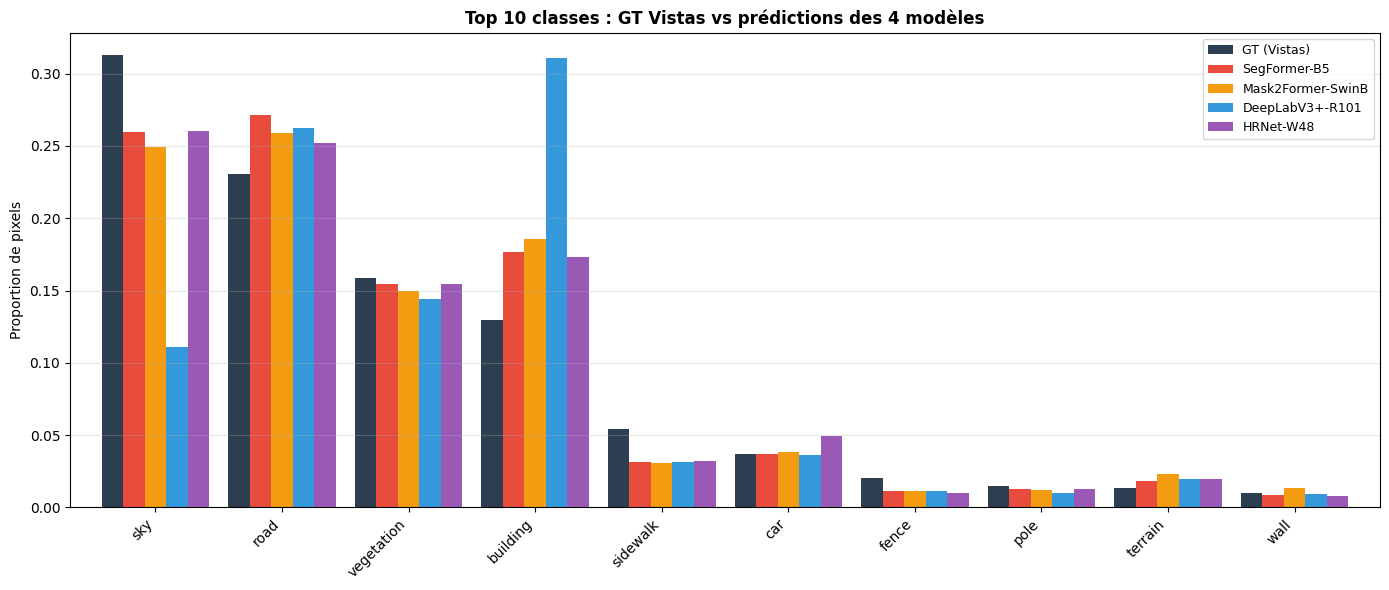

In [15]:
# Distribution GT (accumulée)
gt_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
for img_path in val_images:
    lbl_path = VAL_LBL_DIR / (img_path.stem + ".png")
    img = load_image_resized(img_path)
    gt = load_gt_mapped(lbl_path, img.size)
    for c in range(NUM_CLASSES):
        gt_counts[c] += (gt == c).sum()

distrib = {"GT (Vistas)": gt_counts / gt_counts.sum()}
for name, res in all_results.items():
    distrib[name] = res["class_counts"] / res["class_counts"].sum()

distrib_df = pd.DataFrame(distrib, index=CITYSCAPES_LABELS)
distrib_df = distrib_df.sort_values(by="GT (Vistas)", ascending=False)
distrib_df.to_csv(OUTPUT_DIR / "class_distribution.csv")

fig, ax = plt.subplots(figsize=(14, 6))
distrib_df.head(10).plot(kind="bar", ax=ax, width=0.85,
                          color=["#2c3e50", "#e74c3c", "#f39c12", "#3498db", "#9b59b6"])
ax.set_ylabel("Proportion de pixels")
ax.set_title("Top 10 classes : GT Vistas vs prédictions des 4 modèles",
             fontweight="bold")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distribution.png", dpi=110, bbox_inches="tight")
plt.show()


## 12. Visualisation segmentée avec étiquettes de classe

Pour les 3 images témoins :
- Image originale
- GT (Vistas mappée vers Cityscapes 19) avec étiquettes
- 4 prédictions des modèles avec étiquettes

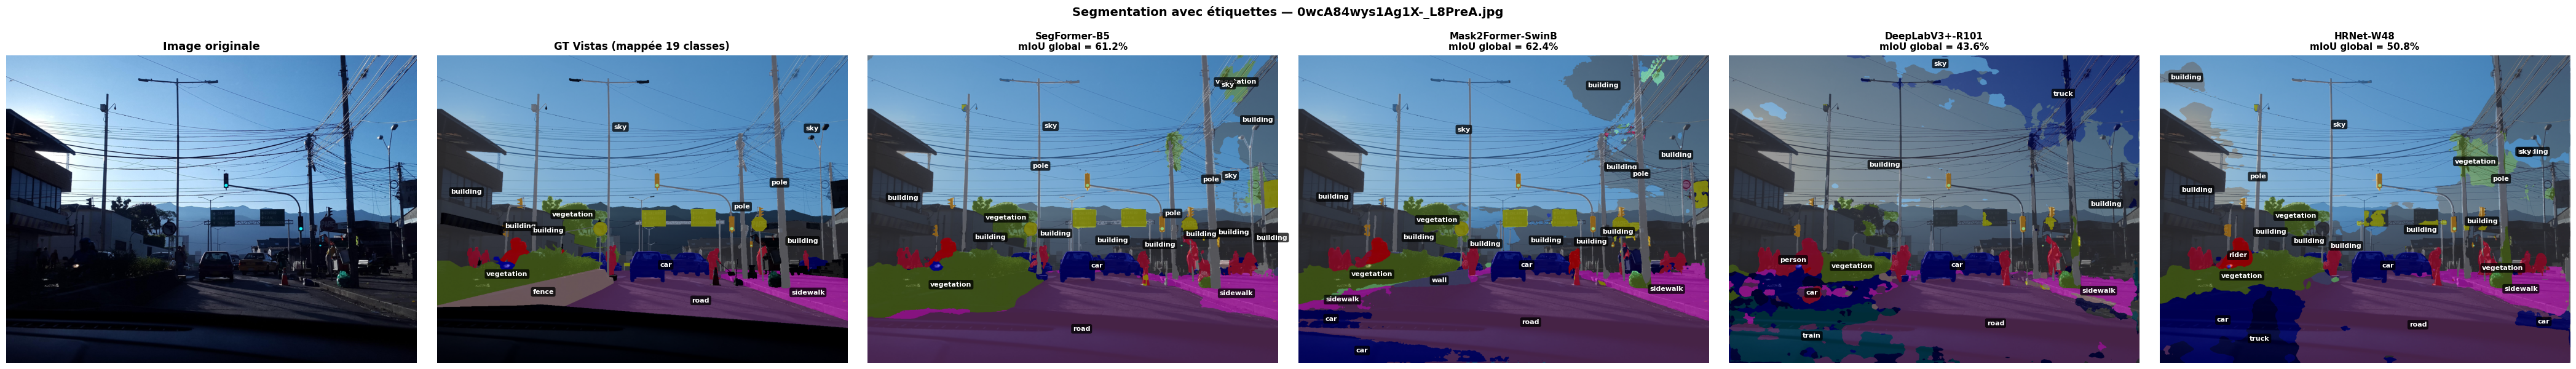

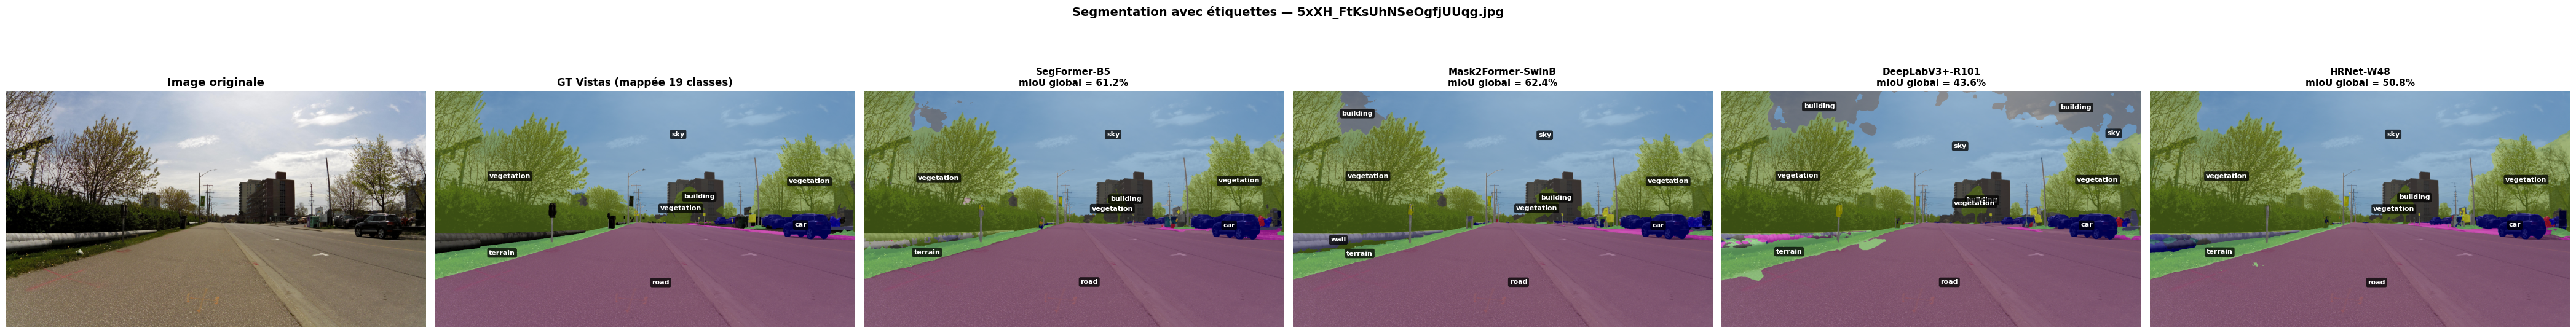

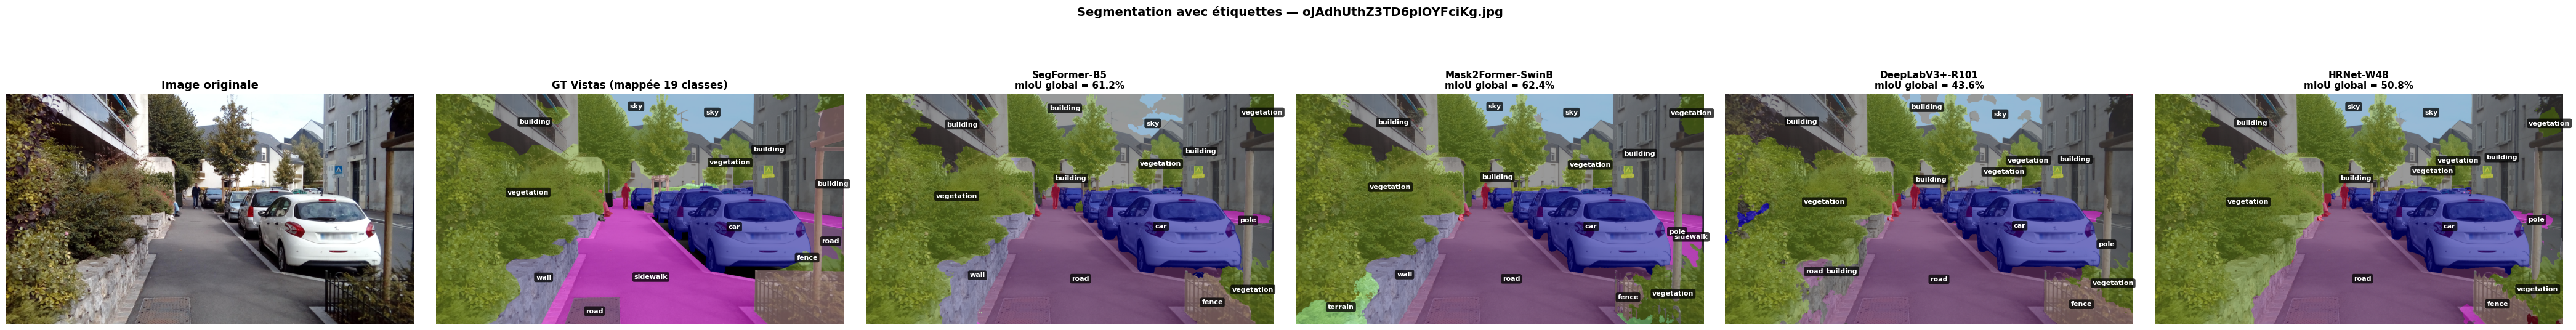


3 visualisations dans C:\Users\youss\Downloads\coolpath_local\data\outputs\vistas_eval_4models\labeled_segmentations


In [18]:
from skimage.measure import label as cc_label, regionprops


def draw_segmented_with_labels(ax, image_arr, mask, alpha=0.55, min_area_frac=0.005):
    """Overlay segmentation + étiquettes de classe au centre des segments."""
    color = colorize(mask)
    blended = ((1 - alpha) * image_arr + alpha * color).astype(np.uint8)
    ax.imshow(blended)

    h, w = mask.shape
    min_area = int(min_area_frac * h * w)

    for class_id in np.unique(mask):
        if class_id >= NUM_CLASSES:
            continue
        binary = (mask == class_id).astype(np.uint8)
        labeled = cc_label(binary)
        for region in regionprops(labeled):
            if region.area >= min_area:
                cy, cx = region.centroid
                ax.text(cx, cy, CITYSCAPES_LABELS[class_id],
                        ha="center", va="center",
                        fontsize=8, color="white", fontweight="bold",
                        bbox=dict(boxstyle="round,pad=0.25",
                                  facecolor="black", alpha=0.75,
                                  edgecolor="none"))
    ax.axis("off")


LABELED_DIR = OUTPUT_DIR / "labeled_segmentations"
LABELED_DIR.mkdir(parents=True, exist_ok=True)

# Récupère les sample_preds depuis le premier modèle (l'image et le GT sont identiques)
first_model = next(iter(all_results.keys()))
sample_image_names = list(all_results[first_model]["sample_preds"].keys())

for img_name in sample_image_names:
    sample = all_results[first_model]["sample_preds"][img_name]
    image_arr = sample["image"]
    gt = sample["gt"]

    n_models = len(all_results)
    # 2 (orig + GT) + n_models panneaux
    fig, axes = plt.subplots(1, 2 + n_models, figsize=(7 * (2 + n_models), 6))

    axes[0].imshow(image_arr)
    axes[0].set_title("Image originale", fontweight="bold", fontsize=13)
    axes[0].axis("off")

    draw_segmented_with_labels(axes[1], image_arr, gt)
    axes[1].set_title("GT Vistas (mappée 19 classes)", fontweight="bold", fontsize=12)

    for ax, model_name in zip(axes[2:], all_results.keys()):
        pred = all_results[model_name]["sample_preds"][img_name]["pred"]
        miou_v = miou_per_model[model_name] * 100
        draw_segmented_with_labels(ax, image_arr, pred)
        ax.set_title(f"{model_name}\nmIoU global = {miou_v:.1f}%",
                     fontweight="bold", fontsize=11)

    plt.suptitle(f"Segmentation avec étiquettes — {img_name}",
                 fontweight="bold", fontsize=14, y=1.02)
    plt.tight_layout()
    out_path = LABELED_DIR / f"labeled_{Path(img_name).stem}.png"
    plt.savefig(out_path, dpi=100, bbox_inches="tight")
    plt.show()
    plt.close()

print(f"\n{len(sample_image_names)} visualisations dans {LABELED_DIR}")


## 13. Résumé final

In [19]:
print("=" * 70)
print(f"  ÉVALUATION VISTAS VAL ({len(val_images)} images) — 4 MODÈLES")
print("=" * 70)
print()
print(f"{'Modèle':<25s} {'mIoU':>8s} {'FPS':>8s} {'Avg time':>12s}")
print("-" * 56)
for name in sorted(miou_per_model, key=lambda x: -miou_per_model[x]):
    miou = miou_per_model[name] * 100
    fps = speed_data[name]["fps"]
    mean_ms = speed_data[name]["mean_ms"]
    print(f"{name:<25s} {miou:>6.2f}% {fps:>8.2f} {mean_ms:>10.0f}ms")
print()
print(f"Sorties dans : {OUTPUT_DIR}")


  ÉVALUATION VISTAS VAL (2000 images) — 4 MODÈLES

Modèle                        mIoU      FPS     Avg time
--------------------------------------------------------
Mask2Former-SwinB          62.42%     1.35        743ms
SegFormer-B5               61.24%     1.00       1003ms
HRNet-W48                  50.82%     2.01        497ms
DeepLabV3+-R101            43.62%     1.08        922ms

Sorties dans : C:\Users\youss\Downloads\coolpath_local\data\outputs\vistas_eval_4models
